## Data Cleaning and Processing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading the filtered dataset (already scraped and filtered down to Data Analyst / Business Analyst / MIS roles)
data = pd.read_csv("naukri_final_filtered.csv")

# checking how many blanks are in each column before doing anything else
print(data.isnull().sum())

# --- cleaning the experience column ---
# experience looks like "3-6 Yrs" right now, which is just text
# doing this split before filling nulls, so "Not Specified" text doesn't mix in with real numbers
cleaned = data["experience"].str.replace(" Yrs", "")
data[["min_experience", "max_experience"]] = cleaned.str.split("-", expand=True)
data[["min_experience", "max_experience"]] = data[["min_experience", "max_experience"]].astype("Int64")

# now that the number columns are made, filling the remaining blanks with a proper label
data["experience"] = data["experience"].fillna("Not Specified")
data["skills"] = data["skills"].fillna("Not Specified")

# --- cleaning the skills column ---
# skills are messy right now, same skill written in different cases like "Excel" and "excel"
# going row by row and fixing the casing and extra spaces
cleaned_skills = []

for s in data['skills']:
    if s == 'Not Specified':
        cleaned_skills.append(s)
    else:
        parts = s.split(',')
        new_parts = []
        for p in parts:
            new_parts.append(p.strip().lower())
        cleaned_skills.append(', '.join(new_parts))

data['skills_clean'] = cleaned_skills

# a couple of skills mean the same thing but got written differently (like "excel" vs "advanced excel")
# merging those here so the skill count later is accurate
data['skills_clean'] = data['skills_clean'].str.replace('advanced excel', 'excel')

# quick check that everything worked
print(data[['experience', 'min_experience', 'max_experience']].head(8))
print(data[['skills', 'skills_clean']].head(8))

# --- counting how many times each skill shows up across all job posts ---
# putting every single skill mention into one long list first
all_skills = []

for s in data['skills_clean']:
    if s != 'Not Specified':
        parts = s.split(', ')
        for p in parts:
            all_skills.append(p)

print('Total skill mentions collected:', len(all_skills))

# converting the list into a pandas Series so value_counts can be used on it
skill_series = pd.Series(all_skills)
skill_counts = skill_series.value_counts()

print('Top 20 most in-demand skills:')
print(skill_counts.head(20))

# saving the cleaned file so this doesn't need to be redone every time
#data.to_csv("naukri_cleaned_final.csv", index=False)


job_title        0
company          0
location         0
experience       3
salary           0
skills           3
city_searched    0
dtype: int64
  experience  min_experience  max_experience
0    3-6 Yrs               3               6
1    0-1 Yrs               0               1
2    5-7 Yrs               5               7
3    6-8 Yrs               6               8
4   7-12 Yrs               7              12
5   7-10 Yrs               7              10
6    3-6 Yrs               3               6
7    5-7 Yrs               5               7
                                              skills  \
0  Sales Report, VLOOKUP, Advanced Excel, Monthly...   
1  Communication Skills, Lead Generation, Cold Ca...   
2  Data analysis, Statistical analysis, Data mana...   
3  financial analysis, hlookup, macros, data anal...   
4  Business Analyst, Privilege Guard log, Cyberar...   
5  data analyst, visualization, data analysis, bu...   
6  algorithms, python, data analysis, modeling, d...   
7

## Exploratory Data Analysis

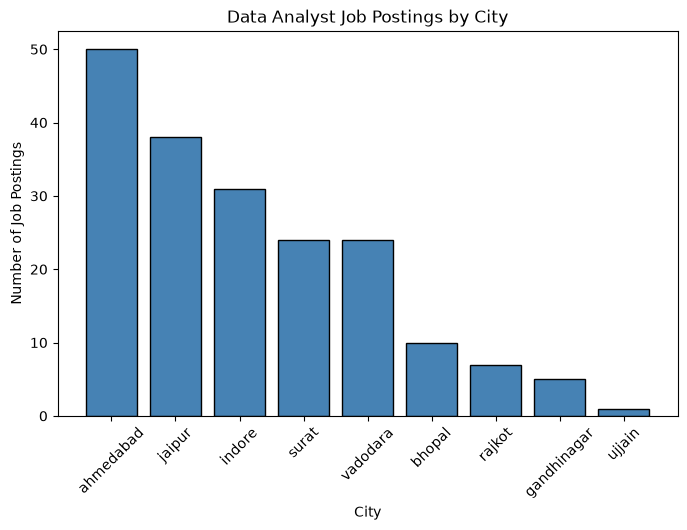

In [5]:
# Chart 1: how many job postings each city has
city_counts = data['city_searched'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(city_counts.index, city_counts.values, color="steelblue", edgecolor="black")

plt.xlabel("City")
plt.ylabel("Number of Job Postings")
plt.title("Data Analyst Job Postings by City")
plt.xticks(rotation=45)

plt.show()


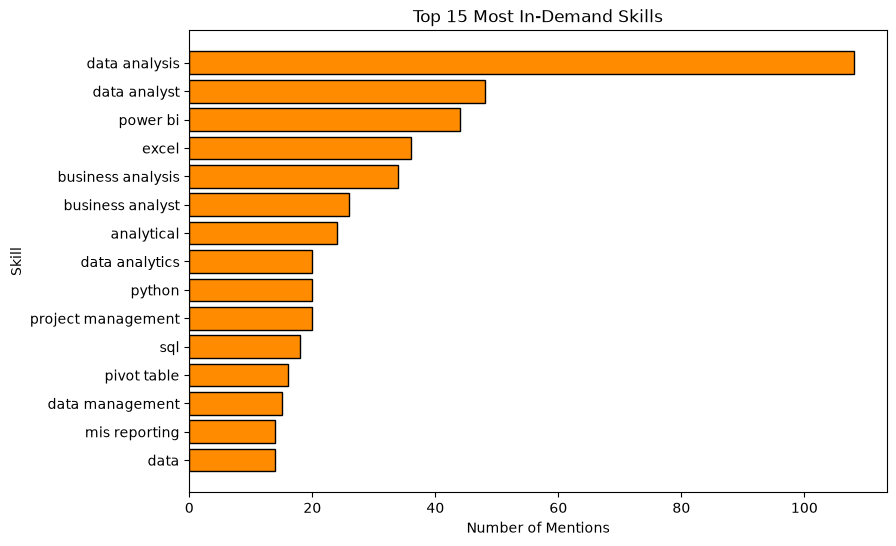

In [6]:
# Chart 2: top 15 most in-demand skills
top_skills = skill_counts.head(15)

plt.figure(figsize=(9,6))
plt.barh(top_skills.index, top_skills.values, color="darkorange", edgecolor="black")

plt.xlabel("Number of Mentions")
plt.ylabel("Skill")
plt.title("Top 15 Most In-Demand Skills")
plt.gca().invert_yaxis()   # so the highest bar shows at the top, not bottom

plt.show()


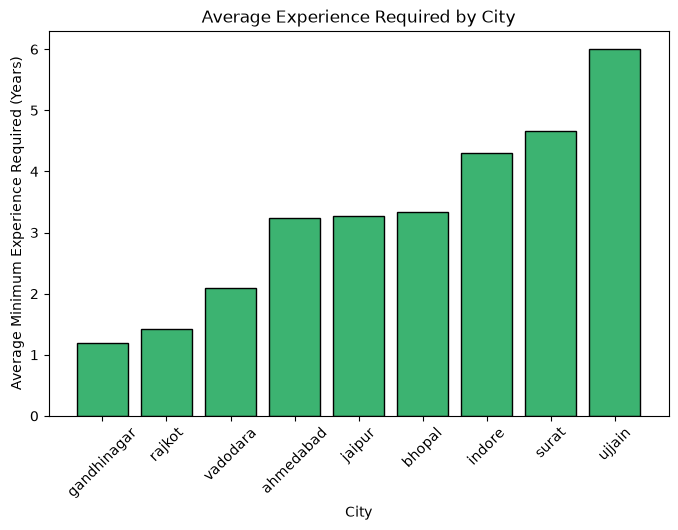

In [7]:
# Chart 3: average minimum experience required, city by city
exp_by_city = data.groupby('city_searched')['min_experience'].mean().sort_values()

plt.figure(figsize=(8,5))
plt.bar(exp_by_city.index, exp_by_city.values, color="mediumseagreen", edgecolor="black")

plt.xlabel("City")
plt.ylabel("Average Minimum Experience Required (Years)")
plt.title("Average Experience Required by City")
plt.xticks(rotation=45)

plt.show()


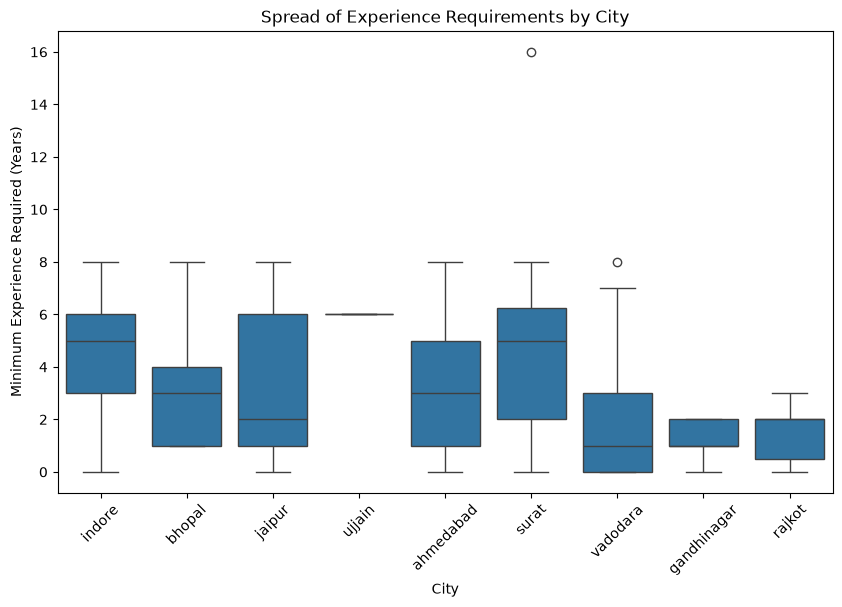

In [8]:
# Chart 4: spread of experience required, not just the average
plt.figure(figsize=(10,6))
sns.boxplot(
    data=data,
    x="city_searched",
    y="min_experience"
)

plt.xlabel("City")
plt.ylabel("Minimum Experience Required (Years)")
plt.title("Spread of Experience Requirements by City")
plt.xticks(rotation=45)

plt.show()


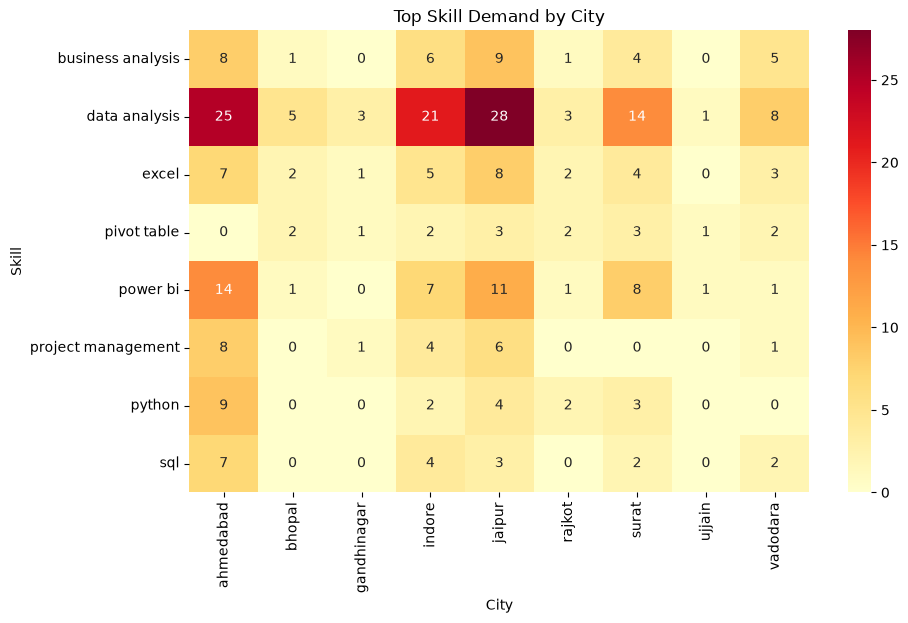

In [9]:
# Chart 5: which top skills are asked for in which city
top_skills_list = ['data analysis','power bi','excel','business analysis','python','sql','pivot table','project management']

rows = []
for i in range(len(data)):
    city = data.loc[i, 'city_searched']
    skills_text = data.loc[i, 'skills_clean']
    if skills_text != 'Not Specified':
        job_skills = skills_text.split(', ')
        for skill in top_skills_list:
            if skill in job_skills:
                rows.append({'city': city, 'skill': skill})

skill_city_df = pd.DataFrame(rows)
cross_tab = pd.crosstab(skill_city_df['skill'], skill_city_df['city'])

plt.figure(figsize=(10,6))
sns.heatmap(cross_tab, annot=True, cmap="YlOrRd", fmt="d")

plt.title("Top Skill Demand by City")
plt.xlabel("City")
plt.ylabel("Skill")

plt.show()
